##  Section 1 — Download Dataset from Kaggle

In [ ]:
# ==========================================
# STEP 1: Install Kaggle API
# ==========================================
!pip install -q kaggle

# Upload your kaggle.json API key
from google.colab import files
files.upload()  # select kaggle.json from your computer

# Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the FGVC Aircraft dataset
!kaggle datasets download -d seryouxblaster764/fgvc-aircraft

# Unzip
!unzip -q fgvc-aircraft.zip -d fgvc_aircraft_dataset

print(" Dataset Downloaded Successfully!")

Saving test.csv to test.csv
Saving train.csv to train.csv
Saving val.csv to val.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/seryouxblaster764/fgvc-aircraft
License(s): other
100% 2.57G/2.57G [02:18<00:00, 19.8MB/s]

✅ Dataset Downloaded Successfully!


##  Section 2 — Explore Dataset Structure

In [ ]:
import os
import pandas as pd

# Quick peek at what was downloaded
for root, dirs, files in os.walk("fgvc_aircraft_dataset"):
    print(root)
    print("  Folders:", dirs[:5])
    print("  Files:",   files[:5])
    print("-" * 50)

fgvc_aircraft_dataset
  Folders: ['fgvc-aircraft-2013b']
  Files: ['test.csv', 'train.csv', 'val.csv']
--------------------------------------------------
fgvc_aircraft_dataset/fgvc-aircraft-2013b
  Folders: ['fgvc-aircraft-2013b']
  Files: []
--------------------------------------------------
fgvc_aircraft_dataset/fgvc-aircraft-2013b/fgvc-aircraft-2013b
  Folders: ['data']
  Files: ['example_evaluation.m', 'evaluation.m', 'README.html', 'vl_pr.m', 'vl_tpfp.m']
--------------------------------------------------
fgvc_aircraft_dataset/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data
  Folders: ['images']
  Files: ['images_family_trainval.txt', 'images_family_test.txt', 'families.txt', 'images_box.txt', 'images_manufacturer_train.txt']
--------------------------------------------------
fgvc_aircraft_dataset/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images
  Folders: []
  Files: ['0921924.jpg', '0987261.jpg', '2137160.jpg', '0996668.jpg', '0492477.jpg']
--------------------------------------

In [ ]:
# Load the CSV label files
TRAIN_CSV = "./fgvc_aircraft_dataset/train.csv"
VAL_CSV   = "./fgvc_aircraft_dataset/val.csv"
TEST_CSV  = "./fgvc_aircraft_dataset/test.csv"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)
print()
train_df.head()

Train: (3334, 3)
Val:   (3333, 3)
Test:  (3333, 3)



,filename,Classes,Labels
0,1025794.jpg,707-320,0
1,1340192.jpg,707-320,0
2,0056978.jpg,707-320,0
3,0698580.jpg,707-320,0
4,0450014.jpg,707-320,0


##  Section 3 — Import All Libraries

In [ ]:
# ==========================================
# ALL IMPORTS
# ==========================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# ==========================================
# REPRODUCIBILITY SEED
# ==========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Libraries Imported!")

✅ Libraries Imported!


##  Section 4 — Setup Device & Paths

In [ ]:
# ==========================================
# DEVICE SETUP
# Use GPU if available
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"  Using Device: {device}")

if torch.cuda.is_available():

    print(f"   GPU: {torch.cuda.get_device_name(0)}")


# ==========================================
# PIN MEMORY
# Useful only when using GPU
# ==========================================

pin_memory = torch.cuda.is_available()


# ==========================================
# RANDOM SEED
# Helps reproducibility
# ==========================================

SEED = 42

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ==========================================
# PATHS
# ==========================================

IMAGE_DIR = "./fgvc_aircraft_dataset/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images"

TRAIN_CSV = "./fgvc_aircraft_dataset/train.csv"

VAL_CSV = "./fgvc_aircraft_dataset/val.csv"

TEST_CSV = "./fgvc_aircraft_dataset/test.csv"


# ==========================================
# OUTPUT MODEL PATH
# ==========================================

MODEL_PATH = "best_aircraft_model.pth"


# ==========================================
# CHECK DATASET
# ==========================================

print(f"\n📁 Image Dir exists: {os.path.isdir(IMAGE_DIR)}")

print(f"📁 Total images found: {len(os.listdir(IMAGE_DIR))}")

# ==========================================
# CUDA SPEED BOOST
# ==========================================
torch.backends.cudnn.benchmark = True


🖥️  Using Device: cuda
   GPU: Tesla T4

📁 Image Dir exists: True
📁 Total images found: 10000


##  Section 5 — Load & Split Data

In [ ]:
# ==========================================
# LOAD CSV FILES
# ==========================================
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# ==========================================
# REMOVE ROWS WHERE IMAGE FILE IS MISSING
# ==========================================
def remove_missing_images(df):
    """Keep only rows whose image file actually exists on disk."""

    valid = []

    for _, row in df.iterrows():

        path = os.path.join(IMAGE_DIR, row["filename"])

        if os.path.exists(path):
            valid.append(row)

    return pd.DataFrame(valid).reset_index(drop=True)


train_df = remove_missing_images(train_df)
val_df   = remove_missing_images(val_df)
test_df  = remove_missing_images(test_df)

# ==========================================
# MERGE ALL DATA, THEN RE-SPLIT
# Better split:
# 80% Train | 10% Validation | 10% Test
# ==========================================
full_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

# ==========================================
# FIRST SPLIT
# 80% Train
# 20% Temp
# ==========================================
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.20,
    stratify=full_df["Labels"],
    random_state=SEED
)

# ==========================================
# SECOND SPLIT
# Temp -> 10% Validation + 10% Test
# ==========================================
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Labels"],
    random_state=SEED
)

# ==========================================
# RESET INDEXES
# ==========================================
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ==========================================
# PRINT DATASET INFO
# ==========================================
print(f"✅ Train:      {len(train_df):,} samples  ({len(train_df)/len(full_df)*100:.1f}%)")

print(f"✅ Validation: {len(val_df):,} samples  ({len(val_df)/len(full_df)*100:.1f}%)")

print(f"✅ Test:       {len(test_df):,} samples  ({len(test_df)/len(full_df)*100:.1f}%)")

print(f"✅ Total classes: {full_df['Labels'].nunique()}")

✅ Train:      8,000 samples  (80.0%)
✅ Validation: 1,000 samples  (10.0%)
✅ Test:       1,000 samples  (10.0%)
✅ Total classes: 100


##  Section 6 — Transforms & Augmentation

In [ ]:

# ==========================================
# FAST HIGH-QUALITY TRANSFORMS
# ==========================================

IMAGE_SIZE = 160

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("✅ Fast High-Quality Transforms Ready!")


✅ Fast High-Quality Transforms Ready!


##  Section 7 — Custom Dataset & DataLoaders

In [ ]:
# ==========================================
# CUSTOM PYTORCH DATASET
# Reads one image at a time from disk.
# ==========================================
class AircraftDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        """
        Args:
            dataframe  : pandas DataFrame with 'filename' and 'Labels' columns
            image_dir  : folder where images are stored
            transform  : torchvision transforms to apply
        """
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        """Total number of samples."""
        return len(self.df)

    def __getitem__(self, idx):
        """Load one image and its label."""
        row        = self.df.iloc[idx]
        img_path   = os.path.join(self.image_dir, row["filename"])
        image      = Image.open(img_path).convert("RGB")   # ensure 3 channels
        label      = int(row["Labels"])

        if self.transform:
            image = self.transform(image)

        return image, label


# ==========================================
# CREATE DATASET OBJECTS
# ==========================================
train_dataset = AircraftDataset(train_df, IMAGE_DIR, train_transform)
val_dataset   = AircraftDataset(val_df,   IMAGE_DIR, val_transform)
test_dataset  = AircraftDataset(test_df,  IMAGE_DIR, val_transform)

# ==========================================
# CREATE DATALOADERS
# batch_size=32 is a solid default.
# num_workers=2 uses 2 CPU threads for loading.
# ==========================================
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("✅ DataLoaders Ready!")
print(f"   Train batches:  {len(train_loader)}")
print(f"   Val batches:    {len(val_loader)}")
print(f"   Test batches:   {len(test_loader)}")

✅ DataLoaders Ready!
   Train batches:  250
   Val batches:    32
   Test batches:   32


## 🧠 Section 8 — CNN Model Architecture (From Scratch)

In [ ]:
# ==========================================
# CNN BUILT COMPLETELY FROM SCRATCH
# No pretrained weights. No ResNet. No VGG.
#
# Architecture Overview:
# ┌──────────────────────────────────┐
# │  Input: 3 x 224 x 224           │
# ├──────────────────────────────────┤
# │  Block 1: Conv 3→32,  MaxPool   │  → 32 x 112 x 112
# │  Block 2: Conv 32→64, MaxPool   │  → 64 x  56 x  56
# │  Block 3: Conv 64→128,MaxPool   │  → 128 x 28 x  28
# │  Block 4: Conv 128→256,MaxPool  │  → 256 x 14 x  14
# ├──────────────────────────────────┤
# │  Global Average Pooling         │  → 256 x   1 x   1
# ├──────────────────────────────────┤
# │  FC 256 → 512 → 100             │
# └──────────────────────────────────┘
# ==========================================

class AircraftCNN(nn.Module):

    def __init__(self, num_classes=100):
        super(AircraftCNN, self).__init__()

        # ------------------------------------------
        # BLOCK 1 — Extract low-level features
        #   e.g. edges, colours
        # Input:  3 x 224 x 224
        # Output: 32 x 112 x 112
        # ------------------------------------------
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # keep spatial size
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),         # halve spatial size
            nn.Dropout2d(0.1)                              # light spatial dropout
        )

        # ------------------------------------------
        # BLOCK 2 — Learn more complex textures
        # Input:  32 x 112 x 112
        # Output: 64 x  56 x  56
        # ------------------------------------------
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.1)
        )

        # ------------------------------------------
        # BLOCK 3 — Learn shapes / aircraft outlines
        # Input:  64 x  56 x  56
        # Output: 128 x 28 x  28
        # ------------------------------------------
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2)
        )

        # ------------------------------------------
        # BLOCK 4 — Learn high-level part features
        # Input:  128 x 28 x 28
        # Output: 256 x 14 x 14
        # ------------------------------------------
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2)
        )

        # ------------------------------------------
        # GLOBAL AVERAGE POOLING
        # Replaces a huge Flatten layer.
        # Collapses 256 x 14 x 14 → 256 x 1 x 1
        # Reduces parameters and overfitting.
        # ------------------------------------------
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # ------------------------------------------
        # FULLY CONNECTED CLASSIFIER HEAD
        # 256 → 512 → 100 (one score per class)
        # ------------------------------------------
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # 256 x 1 x 1 → 256

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),               # strong dropout to prevent overfitting

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)    # output logits, one per class
        )

        # ------------------------------------------
        # WEIGHT INITIALISATION
        # Kaiming Normal is best practice for ReLU.
        # ------------------------------------------
        self._init_weights()

    def _init_weights(self):
        """Initialise all layers using Kaiming Normal (best for ReLU networks)."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """Forward pass: input image → class scores."""
        x = self.block1(x)       # low-level features
        x = self.block2(x)       # mid-level features
        x = self.block3(x)       # higher features
        x = self.block4(x)       # high-level features
        x = self.gap(x)          # global average pool
        x = self.classifier(x)   # FC → class scores
        return x


# ==========================================
# INSTANTIATE THE MODEL
# ==========================================
NUM_CLASSES = 100
model = AircraftCNN(num_classes=NUM_CLASSES).to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

AircraftCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2,

## Section 9 — Training Configuration

In [ ]:



NUM_EPOCHS = 60

BATCH_SIZE = 64

LEARNING_RATE = 0.0005

WEIGHT_DECAY = 1e-4

PATIENCE = 20

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("✅ Fast Improved Training Config Ready!")

print(f"   Epochs:         {NUM_EPOCHS}")
print(f"   Batch Size:     {BATCH_SIZE}")
print(f"   Learning Rate:  {LEARNING_RATE}")
print(f"   Weight Decay:   {WEIGHT_DECAY}")
print(f"   Early Stop:     {PATIENCE}")


✅ Fast Improved Training Config Ready!
   Epochs:         60
   Batch Size:     64
   Learning Rate:  0.0005
   Weight Decay:   0.0001
   Early Stop:     20


## 🏋️ Section 10 — Training Loop




In [ ]:

history = {
    "train_loss":     [],
    "val_loss":       [],
    "train_accuracy": [],
    "val_accuracy":   []
}

best_val_loss = float("inf")  
best_val_acc  = 0.0           
best_epoch    = 0              
es_counter    = 0              



for epoch in range(NUM_EPOCHS):

    model.train()           

    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()          
        outputs = model(images)     
        loss    = criterion(outputs, labels)  

        loss.backward()           

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()               # update weights

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100.0 * correct / total

   
    model.eval()            # disable dropout, use running stats for BatchNorm

    val_running_loss = 0.0
    val_correct      = 0
    val_total        = 0

    with torch.no_grad():   # no gradient computation during evaluation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc  = 100.0 * val_correct / val_total

    # ==============================
    # --- SAVE BEST MODEL ---
    # ==============================
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_val_loss = val_loss
        best_epoch    = epoch + 1

        torch.save(model.state_dict(), MODEL_PATH)
        saved_marker = "  ★ BEST saved!"
    else:
        saved_marker = ""

    # ==============================
    # --- RECORD HISTORY ---
    # ==============================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

  
    scheduler.step(val_loss)


    if val_loss < best_val_loss:
        es_counter = 0
    else:
        es_counter += 1


    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch [{epoch+1:>2}/{NUM_EPOCHS}]  "
        f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  "
        f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%  "
        f"LR: {current_lr:.6f}"
        f"{saved_marker}"
    )

    if es_counter >= PATIENCE:
        print(f"\n⛔ Early Stopping triggered at epoch {epoch+1}!")
        print(f"   No improvement for {PATIENCE} consecutive epochs.")
        break

print(f"\n🏆 Best Model: Epoch {best_epoch}  "
      f"Val Acc: {best_val_acc:.2f}%  Val Loss: {best_val_loss:.4f}")

Epoch [ 1/60]  Train Loss: 4.7931  Train Acc: 1.39%  Val Loss: 4.5572  Val Acc: 2.00%  LR: 0.000500  ★ BEST saved!
Epoch [ 2/60]  Train Loss: 4.6864  Train Acc: 1.79%  Val Loss: 4.5037  Val Acc: 2.50%  LR: 0.000500  ★ BEST saved!
Epoch [ 3/60]  Train Loss: 4.6079  Train Acc: 1.75%  Val Loss: 4.4816  Val Acc: 3.60%  LR: 0.000500  ★ BEST saved!
Epoch [ 4/60]  Train Loss: 4.5850  Train Acc: 2.15%  Val Loss: 4.4551  Val Acc: 3.90%  LR: 0.000500  ★ BEST saved!
Epoch [ 5/60]  Train Loss: 4.5516  Train Acc: 2.70%  Val Loss: 4.4243  Val Acc: 3.60%  LR: 0.000500
Epoch [ 6/60]  Train Loss: 4.5178  Train Acc: 2.77%  Val Loss: 4.3913  Val Acc: 5.10%  LR: 0.000500  ★ BEST saved!
Epoch [ 7/60]  Train Loss: 4.4913  Train Acc: 2.84%  Val Loss: 4.3660  Val Acc: 5.60%  LR: 0.000500  ★ BEST saved!
Epoch [ 8/60]  Train Loss: 4.4540  Train Acc: 3.31%  Val Loss: 4.3305  Val Acc: 5.80%  LR: 0.000500  ★ BEST saved!
Epoch [ 9/60]  Train Loss: 4.4215  Train Acc: 3.81%  Val Loss: 4.2603  Val Acc: 7.60%  LR: 0.00

##  Section 11 — Training Curves

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
ax = axes[0]
ax.plot(history["train_accuracy"], label="Train Accuracy",      color="steelblue",  linewidth=2)
ax.plot(history["val_accuracy"],   label="Validation Accuracy",  color="darkorange", linewidth=2)
ax.axvline(x=best_epoch - 1, color="green", linestyle="--", label=f"Best Epoch ({best_epoch})")
ax.set_title("Accuracy vs Epoch", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Loss ---
ax = axes[1]
ax.plot(history["train_loss"], label="Train Loss",     color="steelblue",  linewidth=2)
ax.plot(history["val_loss"],   label="Validation Loss", color="darkorange", linewidth=2)
ax.axvline(x=best_epoch - 1, color="green", linestyle="--", label=f"Best Epoch ({best_epoch})")
ax.set_title("Loss vs Epoch", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("FGVC Aircraft CNN — Training Curves", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved as training_curves.png")

##  Section 12 — Load Best Model & Evaluate on Test Set

In [ ]:

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"✅ Best model loaded from: {MODEL_PATH}")
print(f"   Best epoch was: {best_epoch}")
print(f"   Best val acc:   {best_val_acc:.2f}%")

In [ ]:

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        labels  = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# TEST ACCURACY

test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\n🎯 Final Test Accuracy: {test_acc:.2f}%")

##  Section 13 — Classification Report

In [ ]:

print("Classification Report:")
print("-" * 60)
print(classification_report(all_labels, all_preds, zero_division=0))

##  Section 14 — Confusion Matrix

In [ ]:

cm = confusion_matrix(all_labels, all_preds)

print(f"Confusion Matrix Shape: {cm.shape}")

fig, ax = plt.subplots(figsize=(18, 16))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title("Confusion Matrix — FGVC Aircraft (100 Classes)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")

## Section 15 — Prediction Visualization on New Random Test Images

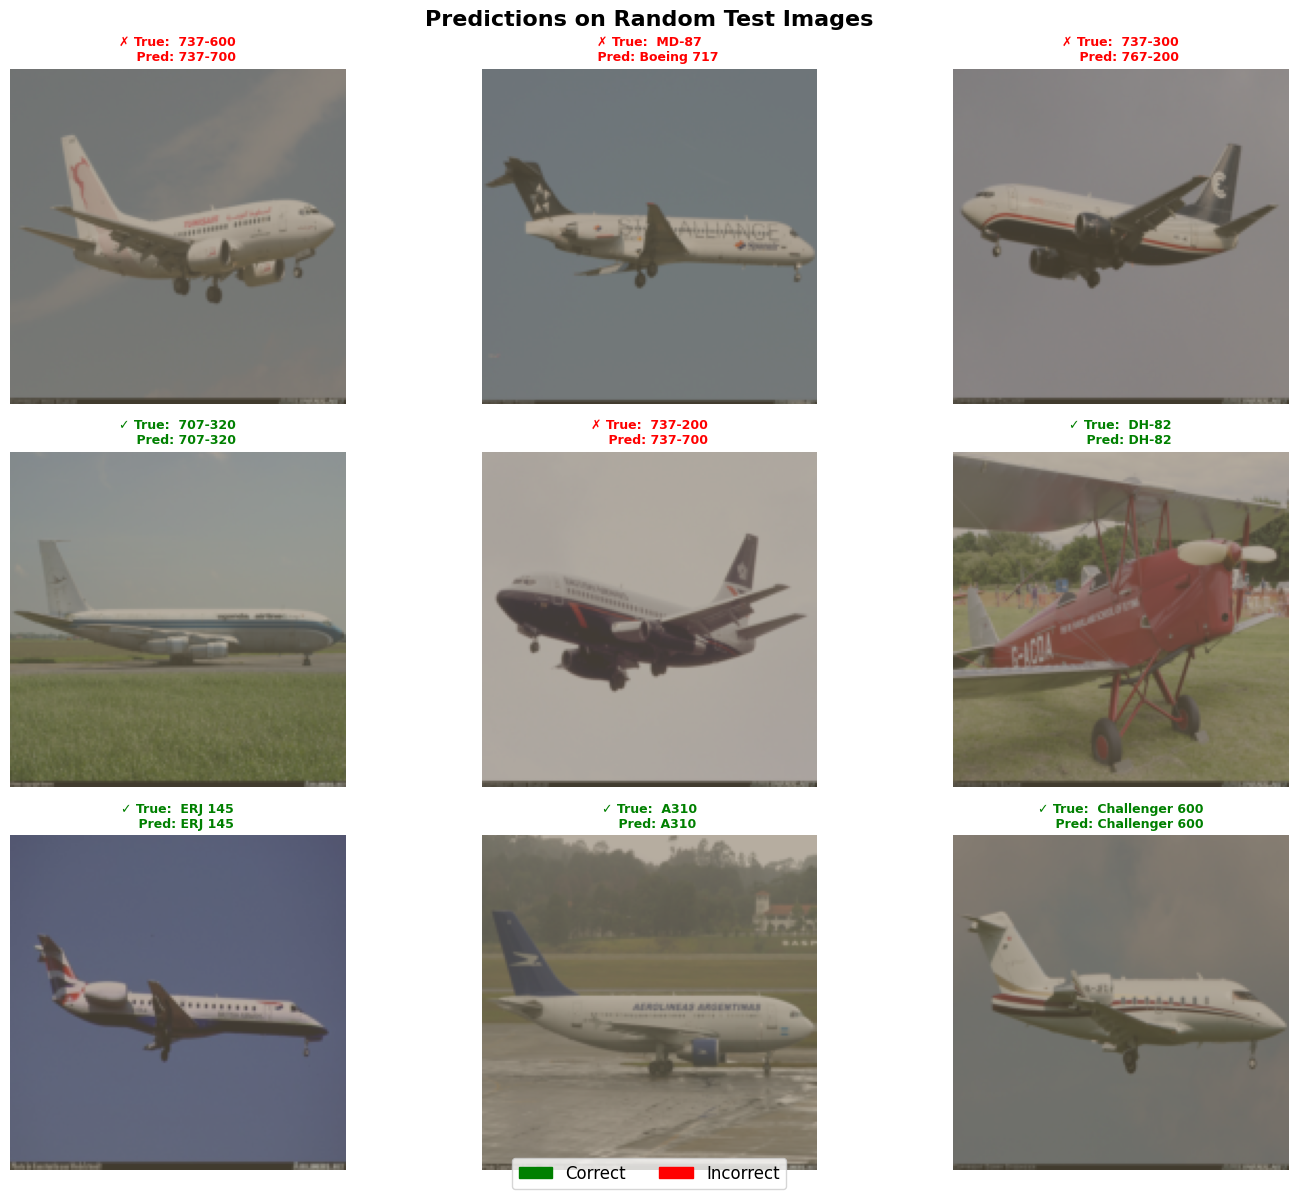

✅ Predictions saved as predictions.png
💡 Re-run this cell to get a fresh batch of random images!


In [ ]:

label_to_class = dict(zip(train_df["Labels"], train_df["Classes"]))


model.eval()

# Unnormalise helper — reverse the Normalize transform for display
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def unnormalize(tensor_img):
    """Convert a normalised tensor back to displayable numpy array."""
    img = tensor_img.permute(1, 2, 0).cpu().numpy()
    img = img * STD + MEAN
    return np.clip(img, 0, 1)

# Pick 9 unique random indices from the test set
indices = random.sample(range(len(test_dataset)), 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Predictions on Random Test Images",
             fontsize=16, fontweight="bold")

for ax, idx in zip(axes.flat, indices):

    # Load single image
    image, true_label = test_dataset[idx]

    # Forward pass
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        pred_label = torch.argmax(output, dim=1).item()

    # Readable class names
    true_name = label_to_class.get(true_label, str(true_label))
    pred_name = label_to_class.get(pred_label, str(pred_label))

    # Display
    ax.imshow(unnormalize(image))
    ax.axis("off")

    # Green title = correct, Red = wrong
    correct = (true_label == pred_label)
    color   = "green" if correct else "red"
    symbol  = "✓" if correct else "✗"

    ax.set_title(
        f"{symbol} True:  {true_name}\n    Pred: {pred_name}",
        fontsize=9,
        color=color,
        fontweight="bold"
    )

# Legend
green_patch = mpatches.Patch(color='green', label='Correct')
red_patch   = mpatches.Patch(color='red',   label='Incorrect')
fig.legend(handles=[green_patch, red_patch], loc='lower center',
           ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Predictions saved as predictions.png")
print("💡 Re-run this cell to get a fresh batch of random images!")

##  Section 16 — Quantitative Evaluation Table

In [ ]:


import pandas as pd

results_table = pd.DataFrame({
    "Metric": [
        "Best Validation Accuracy",
        "Best Validation Loss",
        "Final Test Accuracy",
        "Epochs Trained"
    ],
    "Value": [
        f"{best_val_acc:.2f}%",
        f"{best_val_loss:.4f}",
        f"{test_acc:.2f}%",
        len(history['train_loss'])
    ]
})

print(results_table)


##  Section 17 — Final Summary

In [ ]:

print("=" * 55)
print("       FGVC AIRCRAFT CNN — FINAL SUMMARY")
print("=" * 55)
print(f"  Model:             Custom CNN (From Scratch)")
print(f"  Total Parameters:  {total_params:,}")
print(f"  Epochs Trained:    {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"  Best Epoch:        {best_epoch}")
print(f"  Best Val Acc:      {best_val_acc:.2f}%")
print(f"  Best Val Loss:     {best_val_loss:.4f}")
print(f"  Final Test Acc:    {test_acc:.2f}%")
print("=" * 55)